# Probability Theory Review

> Based on *Probability Theory Review for Machine Learning* — Samuel Ieong (CS229)

Probability theory is the mathematical study of uncertainty. It plays a central role in machine learning — learning algorithms frequently rely on probabilistic assumptions about data.

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Define** probability spaces, random variables, and events using formal notation
2. **Compute** joint, marginal, and conditional probabilities from a joint distribution table
3. **Apply** Bayes' Rule to update beliefs — the foundational operation behind all Bayesian inference
4. **Calculate** expectation, variance, and covariance, and use linearity of expectation correctly
5. **Describe** the Bernoulli, Poisson, and Gaussian distributions and identify which fits a given ML problem
6. **Explain** Jensen's Inequality and why it matters for log-likelihood optimization

> **Prerequisite**: Basic calculus; familiarity with summation notation.
> **How to use**: Read the theory, then trace through each code example step-by-step. The medical test (Bayes' Rule) example is one of the most important — make sure you can reproduce it from scratch.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Basic Concepts

### 1.1 Probability Space

A **probability space** is the triple $(\Omega, \mathcal{F}, P)$:

| Component | Notation | Meaning |
|---|---|---|
| Outcome space | $\Omega$ | Set of all possible outcomes |
| Event space | $\mathcal{F} \subseteq 2^\Omega$ | Set of measurable events |
| Probability measure | $P: \mathcal{F} \to [0,1]$ | Maps events to probabilities |

**Axioms of $\mathcal{F}$:** closed under countable union; closed under complement; contains $\Omega$ and $\emptyset$.

**Axioms of $P$:**
- Non-negativity: $P(\alpha) \geq 0$ for all $\alpha \in \mathcal{F}$
- Trivial event: $P(\Omega) = 1$
- Additivity: $P(\alpha \cup \beta) = P(\alpha) + P(\beta)$ when $\alpha \cap \beta = \emptyset$

In [ ]:
# Fair dice: Ω = {1,2,3,4,5,6}, uniform P
outcomes = [1, 2, 3, 4, 5, 6]
P = {o: 1/6 for o in outcomes}

# Additivity: P({2,4,6}) = P({2}) + P({4}) + P({6})
even_event = {2, 4, 6}
p_even = sum(P[o] for o in even_event)
# 0.5
print(f"P(even) = {p_even}")

# Complement: P(odd) = 1 - P(even)
# 0.5
print(f"P(odd)  = {1 - p_even}")


P(even) = 0.5
P(odd)  = 0.5


### 1.2 Random Variables

A **random variable** $X$ is a function mapping outcomes to real values: $X: \Omega \to \mathbb{R}$.

- Notation: $P(X = a)$ or $P_X(a)$ — probability that $X$ takes value $a$
- $\text{Val}(X)$ — range (set of possible values) of $X$
- **Indicator variable**: $X \in \{0, 1\}$, used to indicate whether an event occurred

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

# Simulate dice throws — X maps outcome to value
throws = rng.integers(1, 7, size=100_000)

# Indicator variable: is_odd = 1 if odd, 0 if even
is_odd = (throws % 2 == 1).astype(int)
print(f"P(X=1 [odd]) ≈ {is_odd.mean():.4f}  (expected 0.5)")

# Empirical distribution of X
for v in range(1, 7):
    print(f"  P(X={v}) ≈ {(throws == v).mean():.4f}  (expected {1/6:.4f})")

P(X=1 [odd]) ≈ 0.5004  (expected 0.5)
  P(X=1) ≈ 0.1670  (expected 0.1667)
  P(X=2) ≈ 0.1669  (expected 0.1667)
  P(X=3) ≈ 0.1652  (expected 0.1667)
  P(X=4) ≈ 0.1669  (expected 0.1667)
  P(X=5) ≈ 0.1681  (expected 0.1667)
  P(X=6) ≈ 0.1659  (expected 0.1667)


### 1.3 Distributions, Joint & Marginal Distributions

**Distribution** $P(X)$: probability of $X$ taking each value in $\text{Val}(X)$.

**Joint distribution** $P(X, Y)$: probability over pairs of values $(a, b)$.

**Marginal distribution** — recover $P(X)$ from joint $P(X, Y)$ by summing out $Y$:

$$P(X = a) = \sum_{b \in \text{Val}(Y)} P(X = a,\, Y = b)$$

The name comes from writing totals in the margins of a joint probability table.

In [ ]:
# Joint distribution: X = dice (1-6), Y = coin flip (0/1)
# P(X=x, Y=y) = 1/12 for all (x, y) — independent, uniform
import pandas as pd

joint = {(x, y): 1/12 for x in range(1, 7) for y in range(2)}

# Marginal of X: sum over Y
p_x = {x: sum(joint[(x, y)] for y in range(2)) for x in range(1, 7)}
print("Marginal P(X):", {k: round(v, 4) for k, v in p_x.items()})

# Marginal of Y: sum over X
p_y = {y: sum(joint[(x, y)] for x in range(1, 7)) for y in range(2)}
print("Marginal P(Y):", {k: round(v, 4) for k, v in p_y.items()})

# Display joint table
df = pd.DataFrame([[joint[(x, y)] for x in range(1, 7)] for y in range(2)],
                   index=["Y=0", "Y=1"], columns=[f"X={x}" for x in range(1, 7)])
print("\nJoint distribution P(X, Y):")
print(df)

Marginal P(X): {1: 0.1667, 2: 0.1667, 3: 0.1667, 4: 0.1667, 5: 0.1667, 6: 0.1667}
Marginal P(Y): {0: 0.5, 1: 0.5}

Joint distribution P(X, Y):
          X=1       X=2       X=3       X=4       X=5       X=6
Y=0  0.083333  0.083333  0.083333  0.083333  0.083333  0.083333
Y=1  0.083333  0.083333  0.083333  0.083333  0.083333  0.083333


### 1.4 Conditional Distributions

The **conditional probability** of $X = a$ given $Y = b$:

$$P(X = a \mid Y = b) = \frac{P(X = a,\, Y = b)}{P(Y = b)}$$

(undefined when $P(Y = b) = 0$)

Extends naturally to multiple conditions:
$$P(X = a \mid Y = b, Z = c) = \frac{P(X = a, Y = b, Z = c)}{P(Y = b, Z = c)}$$

Notation: $P(X \mid Y = b)$ — distribution of $X$ when $Y = b$.

In [ ]:
# P(X=1 | Y=1) where Y=1 means dice throw is odd
# P(X=1, Y=1) = 1/6  (X=1 is odd)
# P(Y=1) = 1/2
# P(X=1, Y=1)
p_x1_y1 = (1/6)
# P(Y=1)
p_y1    = (1/2)
p_cond  = p_x1_y1 / p_y1
print(f"P(X=1 | odd) = {p_cond:.4f}  (expected 1/3 ≈ {1/3:.4f})")

# Verify empirically
throws = rng.integers(1, 7, size=100_000)
odd_mask = throws % 2 == 1
print(f"Empirical P(X=1 | odd) ≈ {(throws[odd_mask] == 1).mean():.4f}")


P(X=1 | odd) = 0.3333  (expected 1/3 ≈ 0.3333)
Empirical P(X=1 | odd) ≈ 0.3317


### 1.5 Independence

$X$ is **independent** of $Y$ (written $X \perp Y$) if:

$$P(X) = P(X \mid Y) \quad \Longleftrightarrow \quad P(X, Y) = P(X)\,P(Y)$$

**Conditional independence** — $X$ and $Y$ are conditionally independent given $Z$:

$$P(X \mid Z) = P(X \mid Y, Z) \quad \Longleftrightarrow \quad P(X, Y \mid Z) = P(X \mid Z)\,P(Y \mid Z)$$

> **ML example (Naïve Bayes):** Words in an email are assumed conditionally independent of each other given the label (spam/not spam). This simplification works surprisingly well in practice.

In [ ]:
# Check independence: dice X and coin Y
# If independent, P(X=x, Y=y) == P(X=x) * P(Y=y) for all (x, y)
joint_vals  = np.array([joint[(x, y)] for x in range(1, 7) for y in range(2)])
product_vals = np.array([p_x[x] * p_y[y] for x in range(1, 7) for y in range(2)])
print("X ⊥ Y (dice and coin are independent):", np.allclose(joint_vals, product_vals))

# Dependent example: X = dice value, Z = (X > 3)
# P(X=1, Z=True) = 0  but P(X=1)*P(Z=True) = 1/6 * 1/2 ≠ 0
p_x1 = 1/6
p_z_true = 1/2
# X=1 implies X ≤ 3, so Z=False
p_x1_and_z_true = 0.0
print(f"\nP(X=1, Z=True) = {p_x1_and_z_true}")
print(f"P(X=1)*P(Z=True) = {p_x1 * p_z_true:.4f}")
print("X and Z are NOT independent:", not np.isclose(p_x1_and_z_true, p_x1 * p_z_true))


X ⊥ Y (dice and coin are independent): True

P(X=1, Z=True) = 0.0
P(X=1)*P(Z=True) = 0.0833
X and Z are NOT independent: True


### 1.6 Chain Rule and Bayes Rule

**Chain Rule** — decomposes a joint distribution into conditionals:

$$P(X_1, X_2, \ldots, X_n) = P(X_1)\,P(X_2 \mid X_1)\cdots P(X_n \mid X_1, \ldots, X_{n-1})$$

**Bayes Rule** — "inverts" the conditioning:

$$P(X \mid Y) = \frac{P(Y \mid X)\,P(X)}{P(Y)}$$

where $P(Y)$ can be computed via the **law of total probability**:

$$P(Y) = \sum_{a \in \text{Val}(X)} P(Y \mid X = a)\,P(X = a)$$

| Term | Name |
|---|---|
| $P(X \mid Y)$ | Posterior |
| $P(Y \mid X)$ | Likelihood |
| $P(X)$ | Prior |
| $P(Y)$ | Evidence (normalising constant) |

In [ ]:
# Bayes Rule: medical test example
# Disease prevalence (prior): P(D=1) = 0.01
# Test sensitivity:  P(T=1 | D=1) = 0.95
# Test specificity: P(T=0 | D=0) = 0.90  →  P(T=1 | D=0) = 0.10

# prior
p_d1 = 0.01
p_d0 = 1 - p_d1
# likelihood
p_t1_given_d1 = 0.95
p_t1_given_d0 = 0.10

# Law of total probability: P(T=1)
p_t1 = p_t1_given_d1 * p_d1 + p_t1_given_d0 * p_d0

# Bayes Rule: P(D=1 | T=1)
p_d1_given_t1 = (p_t1_given_d1 * p_d1) / p_t1

print(f"P(T=1)           = {p_t1:.4f}")
print(f"P(D=1 | T=1)     = {p_d1_given_t1:.4f}")
print("Despite 95% sensitivity, a positive test gives only ~8.7% chance of disease")
print("(base rate dominates when prevalence is low)")


P(T=1)           = 0.1085
P(D=1 | T=1)     = 0.0876
Despite 95% sensitivity, a positive test gives only ~8.7% chance of disease
(base rate dominates when prevalence is low)


## 2. Defining a Probability Distribution

### 2.1 Discrete Distribution: Probability Mass Function (PMF)

For a discrete random variable (finite or countable range), the **PMF** enumerates:

$$P(X = x_k) = p_k, \quad \sum_k p_k = 1, \quad p_k \geq 0$$

### 2.2 Continuous Distribution: Probability Density Function (PDF)

For a continuous random variable, the **PDF** $f$ satisfies:

$$f(x) \geq 0, \quad \int_{\text{Val}(X)} f(x)\,dx = 1$$

$$P(a \leq X \leq b) = \int_a^b f(x)\,dx$$

> A single point has probability zero: $P(X = c) = 0$ for any $c$.

**CDF**: $F(b) = P(X \leq b) = \int_{-\infty}^{b} f(x)\,dx$

**Joint PDF** for continuous $(X, Y)$:
$$P(a_1 \leq X \leq b_1, a_2 \leq Y \leq b_2) = \int_{a_1}^{b_1}\int_{a_2}^{b_2} f(x, y)\,dy\,dx$$

**Conditional PDF** (continuous case):
$$f(y \mid x) = \frac{f(x, y)}{f(x)}$$

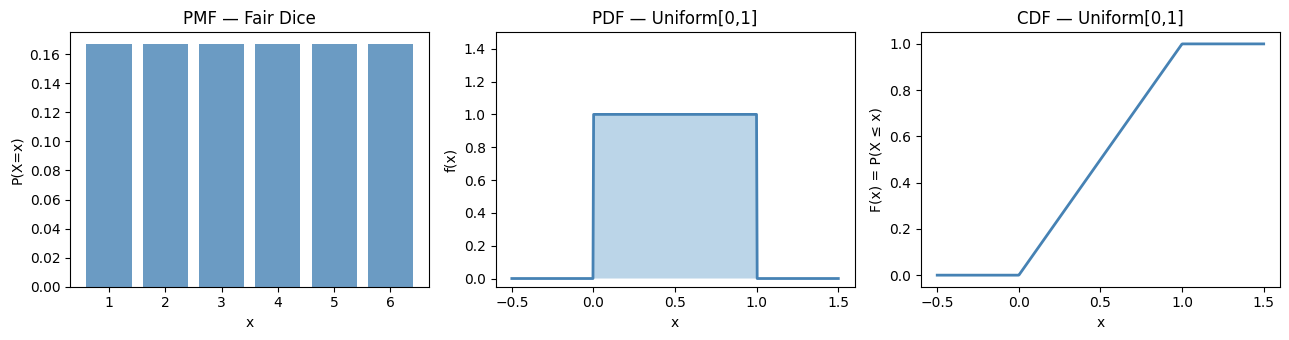

P(X ≤ 0.5) = 0.4999999999999544


In [ ]:
x = np.linspace(-0.5, 1.5, 500)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# PMF: fair dice
ax = axes[0]
vals = np.arange(1, 7)
ax.bar(vals, [1/6]*6, color='steelblue', alpha=0.8)
ax.set_title("PMF — Fair Dice")
ax.set_xlabel("x"); ax.set_ylabel("P(X=x)")
ax.set_xticks(vals)

# PDF: Uniform[0,1]
ax = axes[1]
f_uniform = np.where((x >= 0) & (x <= 1), 1.0, 0.0)
ax.plot(x, f_uniform, 'steelblue', lw=2)
ax.fill_between(x, f_uniform, alpha=0.3)
ax.set_title("PDF — Uniform[0,1]")
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.set_ylim(-0.05, 1.5)

# CDF: Uniform[0,1]
ax = axes[2]
F_uniform = np.clip(x, 0, 1)
ax.plot(x, F_uniform, 'steelblue', lw=2)
ax.set_title("CDF — Uniform[0,1]")
ax.set_xlabel("x"); ax.set_ylabel("F(x) = P(X ≤ x)")

plt.tight_layout()
plt.show()

# Verify: P(X ≤ 0.5) = 0.5
from scipy.integrate import quad
prob, _ = quad(lambda x: 1.0 if 0 <= x <= 1 else 0.0, -np.inf, 0.5)
print(f"P(X ≤ 0.5) = {prob}")

## 3. Expectations and Variance

### 3.1 Expectation

The **expectation** (mean / first moment) of $X$:

$$E(X) = \sum_{a \in \text{Val}(X)} a\,P(X = a) \qquad \text{(discrete)}$$
$$E(X) = \int_{\text{Val}(X)} x\,f(x)\,dx \qquad \text{(continuous)}$$

Key identities:

| Identity | Condition |
|---|---|
| $E(X) = P(X = 1)$ | $X$ is an indicator variable |
| $E(X_1 + \cdots + X_n) = E(X_1) + \cdots + E(X_n)$ | **Linearity** — holds even if dependent |
| $E(XY) = E(X)\,E(Y)$ | Only when $X \perp Y$ |

In [ ]:
# Expectation of fair dice: E[X] = 3.5
vals = np.arange(1, 7)
probs = np.ones(6) / 6
E_X = np.sum(vals * probs)
print(f"E[dice] = {E_X}")

# Linearity: E[X + Y] = E[X] + E[Y] (two independent dice)
dice1 = rng.integers(1, 7, 100_000)
dice2 = rng.integers(1, 7, 100_000)
print(f"\nE[X]         ≈ {dice1.mean():.4f}  (expected 3.5)")
print(f"E[Y]         ≈ {dice2.mean():.4f}  (expected 3.5)")
print(f"E[X+Y]       ≈ {(dice1+dice2).mean():.4f}  (expected 7.0)")
print(f"E[X]+E[Y]    ≈ {dice1.mean() + dice2.mean():.4f}")

# E[XY] = E[X]*E[Y] only when independent
print(f"\nE[X*Y]       ≈ {(dice1*dice2).mean():.4f}")
print(f"E[X]*E[Y]    ≈ {dice1.mean() * dice2.mean():.4f}  (equal since independent)")

E[dice] = 3.5

E[X]         ≈ 3.4943  (expected 3.5)
E[Y]         ≈ 3.4963  (expected 3.5)
E[X+Y]       ≈ 6.9906  (expected 7.0)
E[X]+E[Y]    ≈ 6.9906

E[X*Y]       ≈ 12.2316
E[X]*E[Y]    ≈ 12.2170  (equal since independent)


### 3.2 Variance and Covariance

**Variance** (second moment / spread):

$$\text{Var}(X) = E\left[(X - E(X))^2\right] = E(X^2) - (E(X))^2$$

Standard deviation: $\sigma = \sqrt{\text{Var}(X)}$

Properties:
- $\text{Var}(aX + b) = a^2\,\text{Var}(X)$
- $\text{Var}(X + Y) = \text{Var}(X) + \text{Var}(Y)$ when $X \perp Y$

**Covariance** (measure of joint variability):

$$\text{Cov}(X, Y) = E\left[(X - E(X))(Y - E(Y))\right] = E(XY) - E(X)E(Y)$$

> $\text{Cov}(X, X) = \text{Var}(X)$. If $X \perp Y$ then $\text{Cov}(X,Y) = 0$ (but not vice versa).

---

### 3.3 Covariance Matrix

For a random vector $\mathbf{x} = [X_1, \ldots, X_n]^T$ with mean $\boldsymbol{\mu} = E[\mathbf{x}]$, the **covariance matrix** is:

$$\Sigma = E\!\left[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T\right]$$

In 2D this expands to:

$$\Sigma = \begin{bmatrix} \text{Var}(X_1) & \text{Cov}(X_1, X_2) \\ \text{Cov}(X_2, X_1) & \text{Var}(X_2) \end{bmatrix} = \begin{bmatrix} \sigma_1^2 & \sigma_{12} \\ \sigma_{12} & \sigma_2^2 \end{bmatrix}$$

**Properties:**
- **Symmetric**: $\Sigma = \Sigma^T$ — since $\text{Cov}(X_i, X_j) = \text{Cov}(X_j, X_i)$
- **Positive semi-definite**: $z^T \Sigma z \geq 0$ for all $z \in \mathbb{R}^n$
- **Diagonal entries** are variances: $\Sigma_{ii} = \text{Var}(X_i) \geq 0$

**Shape of $\Sigma$ → shape of the distribution:**

| $\Sigma$ form | Geometry |
|---|---|
| $\sigma^2 I$ | Sphere — equal spread in every direction |
| Diagonal $\begin{bmatrix}\sigma_1^2 & 0 \\ 0 & \sigma_2^2\end{bmatrix}$ | Axis-aligned ellipse |
| Off-diagonal $\sigma_{12} \neq 0$ | Rotated ellipse |

In [ ]:
# Variance of fair dice
E_X  = np.sum(vals * probs)
E_X2 = np.sum(vals**2 * probs)
var_X = E_X2 - E_X**2
print(f"E[X]    = {E_X}")
print(f"E[X²]   = {E_X2:.4f}")
print(f"Var(X)  = {var_X:.4f}  (= 35/12 ≈ {35/12:.4f})")
print(f"Std(X)  = {np.sqrt(var_X):.4f}")

# Var(aX + b) = a^2 Var(X)
a, b = 3.0, 5.0
samples = rng.integers(1, 7, 200_000).astype(float)
print(f"\nVar(X)           ≈ {samples.var():.4f}")
print(f"Var({a}X + {b}) ≈ {(a*samples + b).var():.4f}  (expected {a**2 * samples.var():.4f})")

# Covariance: independent dice should have Cov ≈ 0
cov_indep = np.cov(dice1.astype(float), dice2.astype(float))[0, 1]
print(f"\nCov(X, Y) for independent dice ≈ {cov_indep:.4f}  (expected 0)")

# Dependent: Y = X + noise
X = rng.integers(1, 7, 100_000).astype(float)
Y = X + rng.normal(0, 0.5, 100_000)
cov_dep = np.cov(X, Y)[0, 1]
print(f"Cov(X, X+noise)  ≈ {cov_dep:.4f}  (expected ≈ Var(X) = {X.var():.4f})")

E[X]    = 3.5
E[X²]   = 15.1667
Var(X)  = 2.9167  (= 35/12 ≈ 2.9167)
Std(X)  = 1.7078

Var(X)           ≈ 2.9129
Var(3.0X + 5.0) ≈ 26.2165  (expected 26.2165)

Cov(X, Y) for independent dice ≈ 0.0146  (expected 0)
Cov(X, X+noise)  ≈ 2.9258  (expected ≈ Var(X) = 2.9249)


In [ ]:
rng_cov = np.random.default_rng(0)
n_samp  = 3000

sigma_examples = [
    (np.array([[1.,  0.  ], [0.,  1.  ]]), r"$\Sigma = I$  (spherical)"),
    (np.array([[2.,  1.5 ], [1.5, 2.  ]]), r"$\Sigma$ correlated"),
    (np.array([[4.,  0.  ], [0.,  0.5 ]]), r"$\Sigma$ elongated"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (Sigma, label) in zip(axes, sigma_examples):
    samp  = rng_cov.multivariate_normal([0, 0], Sigma, n_samp)
    S_hat = np.round(np.cov(samp.T), 2)
    ax.scatter(samp[:, 0], samp[:, 1], alpha=0.12, s=4, color='steelblue')
    ax.set_title(f"{label}\ntrue  Σ = {Sigma.tolist()}\nΣ̂ ≈ {S_hat.tolist()}", fontsize=8.5)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.suptitle("Covariance matrix — sample scatter  (n = 3 000)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Important Distributions

### 4.1 Bernoulli

$X \in \{0, 1\}$ with parameter $p = P(X = 1)$:

$$P(X = x) = p^x (1 - p)^{1-x}$$

| | Value |
|---|---|
| Mean | $p$ |
| Variance | $p(1-p)$ |

> **ML use:** Label distribution in logistic regression — $y \mid x \sim \text{Bernoulli}(h_\theta(x))$.

### 4.2 Poisson

Models count of events in a fixed interval; parameter $\lambda$ = average rate:

$$P(X = k) = \frac{e^{-\lambda}\lambda^k}{k!}, \quad k = 0, 1, 2, \ldots$$

| | Value |
|---|---|
| Mean | $\lambda$ |
| Variance | $\lambda$ |

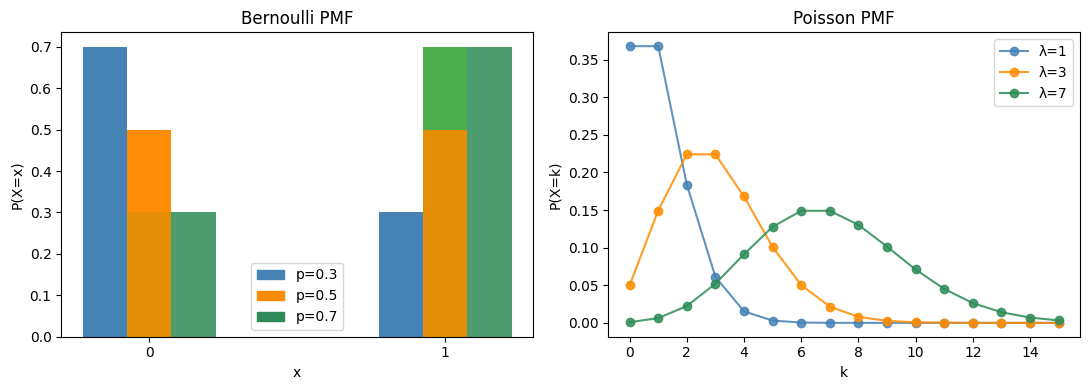

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bernoulli PMF
ax = axes[0]
for p, color in [(0.3, 'steelblue'), (0.5, 'darkorange'), (0.7, 'seagreen')]:
    ax.bar([0 - 0.15 + 0.15*(p > 0.3), 1 - 0.15 + 0.15*(p > 0.3)],
           [1-p, p], width=0.15, label=f"p={p}", alpha=0.85)
ax.bar([0-0.15, 1-0.15], [0.7, 0.3], width=0.15, color='steelblue', alpha=0.85)
ax.bar([0,      1      ], [0.5, 0.5], width=0.15, color='darkorange', alpha=0.85)
ax.bar([0+0.15, 1+0.15 ], [0.3, 0.7], width=0.15, color='seagreen', alpha=0.85)
ax.set_title("Bernoulli PMF")
ax.set_xlabel("x"); ax.set_ylabel("P(X=x)")
ax.set_xticks([0, 1])
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue',label='p=0.3'),
                   Patch(color='darkorange',label='p=0.5'),
                   Patch(color='seagreen',label='p=0.7')])

# Poisson PMF
ax = axes[1]
k = np.arange(0, 16)
for lam, color in [(1, 'steelblue'), (3, 'darkorange'), (7, 'seagreen')]:
    pmf = stats.poisson.pmf(k, lam)
    ax.plot(k, pmf, 'o-', color=color, label=f"λ={lam}", alpha=0.85)
ax.set_title("Poisson PMF")
ax.set_xlabel("k"); ax.set_ylabel("P(X=k)")
ax.legend()

plt.tight_layout()
plt.show()

### 4.3 Gaussian (Normal) Distribution

**Univariate** — parametrised by mean $\mu$ and variance $\sigma^2$:

$$f(x) = \frac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Multivariate** — $k$-dimensional $\mathbf{x} \in \mathbb{R}^k$, parametrised by $\boldsymbol{\mu} \in \mathbb{R}^k$ and covariance matrix $\Sigma \in \mathbb{R}^{k \times k}$:

$$f(\mathbf{x}) = \frac{1}{(2\pi)^{k/2}|\Sigma|^{1/2}}\exp\!\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\Sigma^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

The quadratic form $(\mathbf{x}-\boldsymbol{\mu})^T\Sigma^{-1}(\mathbf{x}-\boldsymbol{\mu})$ is the **Mahalanobis distance** — it measures distance from the mean scaled by the covariance structure.

**How $\Sigma$ shapes the distribution:**

| $\Sigma$ | Contour shape | 3-D bell shape |
|---|---|---|
| $\sigma^2 I$ | Circle | Symmetric bell |
| Diagonal, unequal | Axis-aligned ellipse | Stretched bell |
| Off-diagonal $\neq 0$ | Rotated ellipse | Tilted bell |

> **Key insight:** contour lines $(\mathbf{x}-\boldsymbol{\mu})^T\Sigma^{-1}(\mathbf{x}-\boldsymbol{\mu}) = c$ are ellipses whose axes are the **eigenvectors** of $\Sigma$ and whose radii are proportional to the **square roots of the eigenvalues**.

| | Value |
|---|---|
| Mean | $\boldsymbol{\mu}$ |
| Covariance | $\Sigma$ |
| Notation | $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \Sigma)$ |

In [ ]:
# ── Univariate Gaussians ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
x_1d = np.linspace(-6, 6, 500)
for mu_u, sig_u, label in [
    (0, 1, r'$\mathcal{N}(0,\,1)$'),
    (1, 1, r'$\mathcal{N}(1,\,1)$'),
    (0, 2, r'$\mathcal{N}(0,\,4)$'),
]:
    ax.plot(x_1d, stats.norm.pdf(x_1d, mu_u, sig_u), label=label, lw=2)
ax.set_title("Univariate Gaussian")
ax.set_xlabel("$x$"); ax.set_ylabel("$f(x)$")
ax.legend()
plt.tight_layout()
plt.show()

# ── Multivariate Gaussian: 3 covariance structures ───────────────────────
mv_configs = [
    ([[1, 0],   [0, 1]],    r"$\Sigma = I$  (spherical)"),
    ([[2, 1.5], [1.5, 2]],  r"$\Sigma$ correlated"),
    ([[4, 0],   [0, 0.5]],  r"$\Sigma$ elongated"),
]

mu_2d = [0, 0]
grid   = np.linspace(-3.5, 3.5, 80)
X2, Y2 = np.meshgrid(grid, grid)
pos    = np.dstack((X2, Y2))

# 3-D surface plots
fig = plt.figure(figsize=(15, 5))
for i, (sigma, label) in enumerate(mv_configs):
    Z  = stats.multivariate_normal(mu_2d, sigma).pdf(pos)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.plot_surface(X2, Y2, Z, cmap='coolwarm', linewidth=0, antialiased=True, alpha=0.9)
    ax.set_title(label, pad=8)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$f(x)$")
    ax.view_init(elev=30, azim=-60)
plt.suptitle("Multivariate Gaussian — 3-D surfaces", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Contour plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (sigma, label) in zip(axes, mv_configs):
    Z = stats.multivariate_normal(mu_2d, sigma).pdf(pos)
    ax.contour(X2, Y2, Z, levels=10, cmap='coolwarm')
    ax.set_title(label)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_aspect('equal')
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
plt.suptitle("Multivariate Gaussian — contour plots", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Working with Probabilities

### 5.1 The Log Trick

When optimising over a **product** of probabilities (e.g., likelihood under i.i.d. assumption), take the logarithm first:

$$L(\theta) = \prod_{i=1}^m p(x^{(i)};\theta) \quad\longrightarrow\quad \ell(\theta) = \log L(\theta) = \sum_{i=1}^m \log p(x^{(i)};\theta)$$

- $\log$ is strictly increasing → same $\arg\max$
- Converts products to sums → numerically stable, easier to differentiate
- Avoids underflow from multiplying many small probabilities

**Example (logistic regression):**
$$\ell(\theta) = \sum_{i=1}^m \left[y^{(i)} \log h_\theta(x^{(i)}) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))\right]$$

### 5.2 Delayed Normalization

When performing algebra on distributions, omit the normalization constant $Z$ until needed:

$$p(x) = \frac{1}{Z} \tilde{p}(x) \quad\text{where}\quad Z = \int \tilde{p}(x)\,dx$$

Useful when: finding $\arg\max$ (normalization doesn't affect the optimum), or when the result is guaranteed to be a known distribution (identify the form, read off parameters).

In [ ]:
# Log trick: numerical stability when multiplying many small probabilities
n = 1000
# 0.9^1000 ≈ 2e-46 (underflows to 0)
probs_small = np.full(n, 0.9)

# Direct product — underflows
prod_direct = np.prod(probs_small)
print(f"Direct product:   {prod_direct}   (underflow!)")

# Log-sum — numerically stable
log_prod = np.sum(np.log(probs_small))
print(f"Log sum:          {log_prod:.4f}")
print(f"Recovered:        {np.exp(log_prod):.4e}")
print(f"True value:       {0.9**n:.4e}")

# Log trick for MLE: argmax of product == argmax of log-sum
# Bernoulli MLE: find p that maximises sum of log P(x_i; p)
# true p = 0.7
data = rng.binomial(1, 0.7, 500)
p_grid = np.linspace(0.01, 0.99, 500)
log_lik = np.array([np.sum(np.log(p**data * (1-p)**(1-data))) for p in p_grid])
p_mle = p_grid[np.argmax(log_lik)]
print(f"\nBernoulli MLE: p̂ = {p_mle:.4f}  (true p = 0.7, sample mean = {data.mean():.4f})")


Direct product:   1.7478712517226966e-46   (underflow!)
Log sum:          -105.3605
Recovered:        1.7479e-46
True value:       1.7479e-46

Bernoulli MLE: p̂ = 0.6954  (true p = 0.7, sample mean = 0.6960)


### 5.3 Jensen's Inequality

For a **convex** function $f$ and random variable $X$:

$$f(E(X)) \leq E(f(X))$$

For a **concave** function $f$:

$$f(E(X)) \geq E(f(X))$$

**Intuition:** A straight line connecting two points on a convex function always lies *above* the function. The expected value of $f(X)$ lies on the chord, while $f(E(X))$ lies on the curve — so the chord is above.

**ML uses:**
- EM algorithm derivation: $\log E[\cdot] \geq E[\log(\cdot)]$ (log is concave)
- KL divergence non-negativity: $-\log$ is convex → $\text{KL}(P \| Q) \geq 0$

--- Convex: f(x) = x² ---
f(E[X])  = 6.2385
E[f(X)]  = 7.5696
f(E[X]) ≤ E[f(X)]: True

--- Concave: f(x) = log(x) ---
f(E[X])  = 0.9154
E[f(X)]  = 0.7778
f(E[X]) ≥ E[f(X)]: True


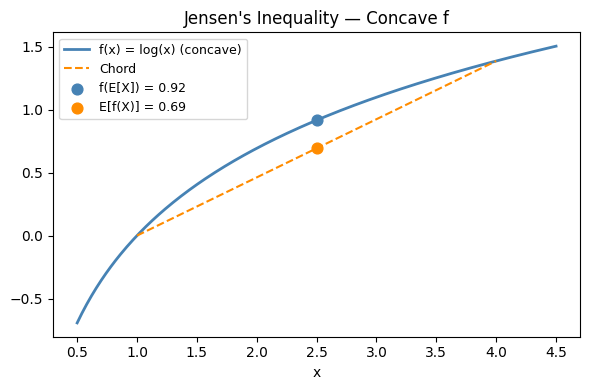

In [ ]:
# Jensen's Inequality: f(E[X]) ≤ E[f(X)] for convex f
X_vals = rng.uniform(0.5, 4.5, 100_000)

# Convex: f(x) = x^2
f_convex = lambda x: x**2
EX = X_vals.mean()
print("--- Convex: f(x) = x² ---")
print(f"f(E[X])  = {f_convex(EX):.4f}")
print(f"E[f(X)]  = {f_convex(X_vals).mean():.4f}")
print(f"f(E[X]) ≤ E[f(X)]: {f_convex(EX) <= f_convex(X_vals).mean()}")

# Concave: f(x) = log(x)
f_concave = np.log
print("\n--- Concave: f(x) = log(x) ---")
print(f"f(E[X])  = {f_concave(EX):.4f}")
print(f"E[f(X)]  = {f_concave(X_vals).mean():.4f}")
print(f"f(E[X]) ≥ E[f(X)]: {f_concave(EX) >= f_concave(X_vals).mean()}")

# Plot illustration
fig, ax = plt.subplots(figsize=(6, 4))
x_plot = np.linspace(0.5, 4.5, 300)
ax.plot(x_plot, np.log(x_plot), 'steelblue', lw=2, label='f(x) = log(x) (concave)')
x1, x2 = 1.0, 4.0
ax.plot([x1, x2], [np.log(x1), np.log(x2)], 'darkorange', lw=1.5, ls='--', label='Chord')
mid = (x1 + x2) / 2
ax.scatter([mid], [np.log(mid)], color='steelblue', s=60, zorder=5, label=f'f(E[X]) = {np.log(mid):.2f}')
ax.scatter([mid], [(np.log(x1)+np.log(x2))/2], color='darkorange', s=60, zorder=5, label=f'E[f(X)] = {(np.log(x1)+np.log(x2))/2:.2f}')
ax.legend(fontsize=9)
ax.set_title("Jensen's Inequality — Concave f")
ax.set_xlabel("x")
plt.tight_layout()
plt.show()

---

## Quick Reference

### Core Rules

| Rule | Formula |
|---|---|
| Conditional probability | $P(X\mid Y) = P(X,Y)/P(Y)$ |
| Independence | $P(X,Y) = P(X)P(Y)$ |
| Chain rule | $P(X_1,\ldots,X_n) = P(X_1)\prod_{i=2}^n P(X_i\mid X_1,\ldots,X_{i-1})$ |
| Bayes rule | $P(X\mid Y) = P(Y\mid X)P(X)/P(Y)$ |
| Marginalisation | $P(X) = \sum_y P(X, Y=y)$ |
| Law of total probability | $P(Y) = \sum_x P(Y\mid X=x)P(X=x)$ |

### Expectation & Variance

| Identity | Formula | Condition |
|---|---|---|
| Linearity | $E[\sum_i X_i] = \sum_i E[X_i]$ | Always |
| Product | $E[XY] = E[X]E[Y]$ | $X \perp Y$ |
| Indicator | $E[\mathbf{1}\{A\}] = P(A)$ | — |
| Variance formula | $\text{Var}(X) = E[X^2] - E[X]^2$ | — |
| Scaling | $\text{Var}(aX+b) = a^2\text{Var}(X)$ | — |
| Sum (indep) | $\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y)$ | $X \perp Y$ |

### Key Distributions

| Distribution | PMF / PDF | Mean | Variance |
|---|---|---|---|
| $\text{Bernoulli}(p)$ | $p^x(1-p)^{1-x}$ | $p$ | $p(1-p)$ |
| $\text{Poisson}(\lambda)$ | $e^{-\lambda}\lambda^k/k!$ | $\lambda$ | $\lambda$ |
| $\mathcal{N}(\mu, \sigma^2)$ | $\frac{1}{\sqrt{2\pi}\sigma}e^{-(x-\mu)^2/2\sigma^2}$ | $\mu$ | $\sigma^2$ |
| $\mathcal{N}(\mu, \Sigma)$ (multivariate) | $\frac{1}{\sqrt{(2\pi)^k\lvert\Sigma\rvert}}e^{-\frac{1}{2}(x-\mu)^T\Sigma^{-1}(x-\mu)}$ | $\mu$ | $\Sigma$ |

### Working Tips

| Technique | When to use |
|---|---|
| Log trick | Optimising products of probabilities; numerical stability |
| Delayed normalisation | Algebra on distributions; finding $\arg\max$ |
| Jensen's inequality | $f(E[X]) \leq E[f(X)]$ for convex $f$ (reverse for concave) |

---
## Practice Exercises

**Conceptual**

1. A disease affects 1% of the population. A test has 99% sensitivity (true positive rate) and 95% specificity (true negative rate). You test positive. What is the probability you have the disease? Work through Bayes' Rule step by step. Is the result surprising?

2. $X$ and $Y$ are independent Gaussian random variables: $X \sim \mathcal{N}(\mu_X, \sigma_X^2)$ and $Y \sim \mathcal{N}(\mu_Y, \sigma_Y^2)$. Show (using moment-generating functions or directly) that $Z = X + Y \sim \mathcal{N}(\mu_X + \mu_Y, \sigma_X^2 + \sigma_Y^2)$. Why does independence matter here?

3. Jensen's Inequality states that for a convex $f$, $f(\mathbb{E}[X]) \leq \mathbb{E}[f(X)]$. Prove that $\text{KL}(P \| Q) = \mathbb{E}_P\left[\log\frac{P(x)}{Q(x)}\right] \geq 0$ using Jensen's Inequality with the concave function $\log$.

4. Covariance $\text{Cov}(X, Y) = 0$ does not imply independence. Construct an explicit counterexample: find two random variables $X$ and $Y$ such that $\text{Cov}(X, Y) = 0$ but $X$ and $Y$ are not independent.

5. The **law of total expectation** states $\mathbb{E}[X] = \mathbb{E}[\mathbb{E}[X | Y]]$. Use it to prove that if $X_1, \ldots, X_n$ are i.i.d. and $N \sim \text{Poisson}(\lambda)$ is independent of all $X_i$, then $\mathbb{E}\left[\sum_{i=1}^N X_i\right] = \lambda \mathbb{E}[X_1]$.

**Numerical**

6. Implement a Monte Carlo simulation to estimate $P(D=1 | T=1)$ for the medical test example (prior $P(D=1) = 0.01$, sensitivity 95%, specificity 90%). Generate 1,000,000 simulated patients, apply the test, and compute the empirical posterior probability. Compare to the exact Bayes' Rule calculation.

7. Simulate Jensen's Inequality visually: for $X \sim \text{Uniform}[0, 4]$ and $f(x) = x^2$, draw 10,000 samples. Estimate $f(\mathbb{E}[X])$ and $\mathbb{E}[f(X)]$ numerically. Plot the function, the chord between $f(0)$ and $f(4)$, and annotate both quantities.

8. Estimate the correlation between two Gaussian random variables with $\Sigma = \begin{bmatrix}1 & 0.8 \\ 0.8 & 1\end{bmatrix}$ using 10,000 samples. Compare to the theoretical $\rho = 0.8$ and plot the joint scatter to visualize the correlation structure.

**Reflection**

9. The Naïve Bayes classifier assumes features are conditionally independent given the class label: $P(x_1, \ldots, x_p | y) = \prod_j P(x_j | y)$. In text classification, this means words are independent given the document class. Why is this assumption clearly wrong (words co-occur non-randomly), yet Naïve Bayes often works well in practice?